# Causal Question I: Average Treatment Effect — Aflibercept vs Ranibizumab

**Question:** On average, does aflibercept cause *faster visual recovery* than ranibizumab, or does it just appear that way because of *when and how* each drug was used?

**Method:** Augmented Inverse Probability Weighting (AIPW) — doubly-robust ATE estimator with 5-fold cross-fitting.

### Design
Here we look at the post-2013 cohort: both drugs were available, so treatment assignment reflects physician/patient factors rather than drug availability. We adjust for observed confounders (age, baseline VA, sex, ethnicity, induction) via AIPW.

### Outcomes — aligned with the original Moorfields study
| Outcome | Type | Horizon | Mirrors Moorfields |
|---------|------|---------|-------------------|
| **Reached VA ≥ 70** (primary) | IPCW-corrected survival | 2 years | Primary outcome |
| VA change from baseline | Continuous | Last visit | Supplementary |
| **Declined to VA ≤ 35** | IPCW-corrected survival | 5 years | Secondary outcome |


**Survival outcomes use IPCW** (inverse probability of censoring weights) to correct for the 2× follow-up gap between aflibercept (median 1.9 yr) and ranibizumab (median 0.8 yr) patients. Without this correction the binary event estimates are biased.

# Additional Augmented Analysis

**Era placebo check** — compares pre-2013 vs post-2013 ranibizumab outcomes after covariate adjustment. If outcomes differ significantly, post-2013 ranibizumab patients are a selected subgroup and pooling is problematic.

**Augmented-control AIPW** — pools pre-2013 ranibizumab with post-2013 ranibizumab as the control arm (~3,800 ranibizumab vs ~3,951 aflibercept), treating `era_post2013` as an additional covariate to absorb era effects. This directly addresses the main weakness of v1: only 590 post-2013 ranibizumab controls.

**Key assumption for the augmented analysis:** era differences in outcomes are fully captured by the observed covariates + `era_post2013` flag. The placebo check tests this.


In [15]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from scipy import stats
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Resolve repo root regardless of where Jupyter/VSCode sets the working directory
ROOT = Path.cwd()
for _p in [Path.cwd()] + list(Path.cwd().parents):
    if (_p / 'input').exists() and (_p / 'output').exists():
        ROOT = _p
        break

PATIENT_CSV = ROOT / 'output' / 'results' / 'cohort_patient.csv'
OUT_TABLES  = ROOT / 'output' / 'tables'
OUT_RESULTS = ROOT / 'output' / 'results'

print(f'Repo root: {ROOT}')
print(f'Data file exists: {PATIENT_CSV.exists()}')

patient = pd.read_csv(PATIENT_CSV)
print(f'Loaded {len(patient):,} patients')
patient[['treatment', 'era_post2013', 'va_baseline', 'va_change',
         'time_to_va70_years', 'event_va70']].describe().round(2)

Repo root: /Users/mmoen/Documents/alaa_3
Data file exists: True
Loaded 7,802 patients


,treatment,era_post2013,va_baseline,va_change,time_to_va70_years,event_va70
count,7802.00,7802.00,7802.00,7802.00,5978.00,5978.00
mean,0.51,0.58,54.68,0.81,1.28,0.44
std,0.50,0.49,15.99,17.81,1.66,0.50
min,0.00,0.00,0.00,-94.00,0.00,0.00
25%,0.00,0.00,45.00,-7.00,0.16,0.00
50%,1.00,1.00,57.00,2.00,0.60,0.00
75%,1.00,1.00,68.00,11.00,1.75,1.00
max,1.00,1.00,100.00,65.00,10.81,1.00


## 1. Setup: covariates and AIPW function

In [16]:
COVARIATES = [
    'age_midpoint',        # continuous age proxy (55/65/75/85)
    'va_baseline',         # ETDRS letter score at first injection
    'female',              # binary sex
    'eth_afro_caribbean',  # ethnicity dummies (white = reference)
    'eth_south_east_asian',
    'eth_unknown',
    'loaded_binary',       # completed 3-injection induction
    'induction_interval',  # mean interval between induction injections (days)
    # eth_other excluded: 0% in ranibizumab post-2013 → near-separation in logistic
]


def ipcw_outcome(time, event, horizon, g_min=0.05, verbose=False):
    """
    Inverse Probability of Censoring Weighted (IPCW) binary outcome with configurable truncation.

    Corrects for informative censoring when computing P(T <= horizon).

    For each patient:
      Y_ipcw = I(T_i <= horizon AND event_i = 1) / G_hat(T_i)
    where G_hat(t) = KM estimate of P(C > t), the censoring survival function.

    Parameters
    ----------
    time    : observed time (event or censoring)
    event   : 1 = event observed, 0 = censored
    horizon : fixed time horizon (years)
    g_min   : minimum allowed censoring survival probability (truncation floor)
    verbose : if True print truncation counts

    Returns
    -------
    y_ipcw  : IPCW-weighted outcome array (use as continuous outcome in AIPW)
    g_hat   : censoring survival probabilities at each observed time (after truncation)
    n_trunc : number of observations with g_hat < g_min before truncation
    """
    time  = np.asarray(time, float)
    event = np.asarray(event, float)

    # Fit KM on censoring (flip event indicator)
    km = KaplanMeierFitter()
    km.fit(time, event_observed=(1 - event))
    g_raw = km.survival_function_at_times(time).values
    n_trunc = int((g_raw < g_min).sum())
    g_hat = np.clip(g_raw, g_min, 1.0)

    if verbose and n_trunc > 0:
        print(f'  IPCW: truncated {n_trunc} censoring probabilities to g_min={g_min}')

    # IPCW outcome: event within horizon, reweighted by inverse censoring probability
    y_ipcw = ((time <= horizon) & (event == 1)).astype(float) / g_hat
    return y_ipcw, g_hat, n_trunc


def aipw_ate(y, d, x, n_folds=5, random_state=42):
    """
    Doubly-robust AIPW ATE estimator with cross-fitting.
    Uses Ridge regression for the outcome model (works for continuous,
    binary, and IPCW-weighted outcomes alike).

    Returns dict: ate, se, ci_lo, ci_hi, t, p, n, ate_direct_stand, e_hat, psi
    """
    n = len(y)
    y, d, x = np.asarray(y, float), np.asarray(d, float), np.asarray(x, float)

    psi   = np.zeros(n)
    e_hat = np.zeros(n)
    mu1   = np.zeros(n)
    mu0   = np.zeros(n)

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    for tr, te in kf.split(x):
        x_tr, x_te = x[tr], x[te]
        d_tr, d_te = d[tr], d[te]
        y_tr, y_te = y[tr], y[te]

        # Propensity: P(D=1 | X)
        ps = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs',
                                random_state=random_state)
        ps.fit(x_tr, d_tr)
        e_te = np.clip(ps.predict_proba(x_te)[:, 1], 0.01, 0.99)

        # Outcome: E[Y | D, X]  — Ridge with standardisation
        x_tr_d  = np.column_stack([x_tr, d_tr])
        x_te_d1 = np.column_stack([x_te, np.ones(len(x_te))])
        x_te_d0 = np.column_stack([x_te, np.zeros(len(x_te))])
        scaler  = StandardScaler()
        out     = Ridge(alpha=1.0)
        out.fit(scaler.fit_transform(x_tr_d), y_tr)
        mu1_te = out.predict(scaler.transform(x_te_d1))
        mu0_te = out.predict(scaler.transform(x_te_d0))

        # AIPW influence function
        psi[te] = (
            mu1_te - mu0_te
            + d_te * (y_te - mu1_te) / e_te
            - (1 - d_te) * (y_te - mu0_te) / (1 - e_te)
        )
        e_hat[te] = e_te
        mu1[te]   = mu1_te
        mu0[te]   = mu0_te

    ate = psi.mean()
    se  = psi.std(ddof=1) / np.sqrt(n)
    t   = ate / se
    p   = 2 * (1 - stats.norm.cdf(abs(t)))

    return {'ate': ate, 'se': se,
            'ci_lo': ate - 1.96 * se, 'ci_hi': ate + 1.96 * se,
            't': t, 'p': p, 'n': n,
            'ate_direct_stand': (mu1 - mu0).mean(),
            'e_hat': e_hat, 'psi': psi}


def compute_ipw_only_ate(y, d, e):
    """Compute IPW-only ATE (no outcome model)."""
    e = np.clip(np.asarray(e, float), 0.001, 0.999)
    y = np.asarray(y, float)
    d = np.asarray(d, float)
    ipw_term = d * (y / e) - (1 - d) * (y / (1 - e))
    return ipw_term.mean()

def compute_outcome_only_ate(y, d, x):
    """Direct standardisation (outcome-model-only) using Ridge on full data."""
    x = np.asarray(x, float)
    d = np.asarray(d, float)
    y = np.asarray(y, float)
    x_d = np.column_stack([x, d])
    x_d1 = np.column_stack([x, np.ones(len(x))])
    x_d0 = np.column_stack([x, np.zeros(len(x))])
    scaler = StandardScaler()
    out = Ridge(alpha=1.0)
    out.fit(scaler.fit_transform(x_d), y)
    mu1 = out.predict(scaler.transform(x_d1))
    mu0 = out.predict(scaler.transform(x_d0))
    return (mu1 - mu0).mean()

def covariate_balance(df, covariates, treatment_col, ipw_weights=None):
    rows = []
    for cov in covariates:
        x = df[cov].values.astype(float)
        d = df[treatment_col].values
        m1, m0 = x[d == 1].mean(), x[d == 0].mean()
        sd = np.sqrt((x[d == 1].var() + x[d == 0].var()) / 2) + 1e-9
        row = {'covariate': cov, 'mean_afli': m1, 'mean_rani': m0,
               'smd_unadj': (m1 - m0) / sd}
        if ipw_weights is not None:
            w  = ipw_weights
            w1 = w[d == 1] / w[d == 1].sum()
            w0 = w[d == 0] / w[d == 0].sum()
            row['mean_afli_ipw'] = (x[d == 1] * w1).sum()
            row['mean_rani_ipw'] = (x[d == 0] * w0).sum()
            row['smd_ipw'] = (row['mean_afli_ipw'] - row['mean_rani_ipw']) / sd
        rows.append(row)
    return pd.DataFrame(rows)


## 2. Primary Analysis: Post-2013 Cohort

Restricting to post-2013 patients is the cleanest comparison: both drugs were available, so treatment assignment reflects physician/patient factors rather than drug availability. We adjust for observed confounders via AIPW.

In [17]:
# Restrict to post-2013, drop rows with missing covariates only
# event_va70 / event_va35 are NaN by design for ineligible patients (already
# above/below threshold at baseline) — do NOT require them here.
post = (
    patient[patient['era_post2013'] == 1]
    .dropna(subset=COVARIATES + ['va_change', 'va_last'])
    .reset_index(drop=True)
)

n_afli = post['treatment'].sum()
n_rani = (post['treatment'] == 0).sum()
print(f'Post-2013 cohort: N={len(post):,}  '
      f'aflibercept={n_afli:,} ({100*n_afli/len(post):.1f}%)  '
      f'ranibizumab={n_rani:,} ({100*n_rani/len(post):.1f}%)')

x_post = post[COVARIATES].values
d_post = post['treatment'].values

# Fit propensity model on full post-2013 set for diagnostics
ps_diag = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs', random_state=42)
ps_diag.fit(x_post, d_post)
e_post = np.clip(ps_diag.predict_proba(x_post)[:, 1], 0.01, 0.99)
post['e_hat'] = e_post

print(f'Propensity scores: mean={e_post.mean():.3f}  '
      f'min={e_post.min():.3f}  max={e_post.max():.3f}')

Post-2013 cohort: N=4,541  aflibercept=3,951 (87.0%)  ranibizumab=590 (13.0%)
Propensity scores: mean=0.870  min=0.575  max=0.933


### 2a. Propensity Score Overlap and Positivity Check

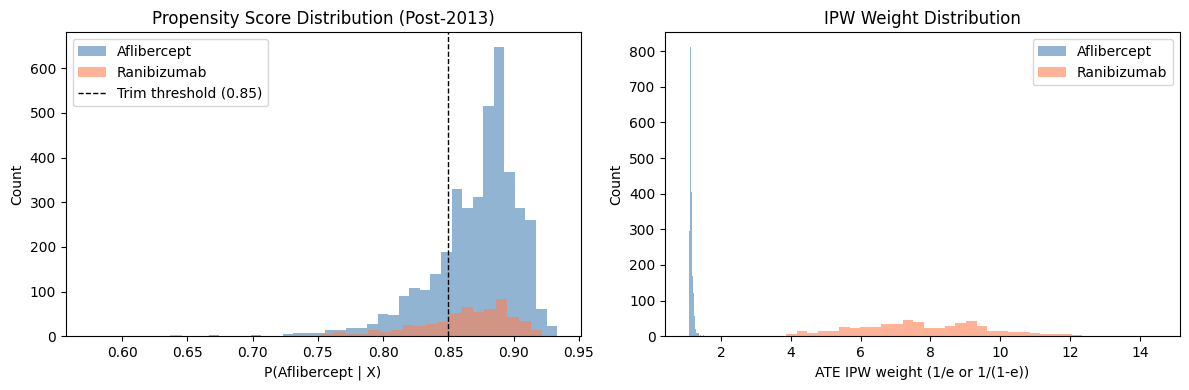

PS range: [0.575, 0.933]  p10=0.823  p25=0.854  p50=0.879  p75=0.893  p90=0.907
IPW weights: mean=2.00  max=14.48  pct >10: 1.5%
Median follow-up — aflibercept: 1.88 yr  ranibizumab: 0.83 yr


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(e_post[d_post == 1], bins=40, alpha=0.6, label='Aflibercept', color='steelblue')
ax.hist(e_post[d_post == 0], bins=40, alpha=0.6, label='Ranibizumab', color='coral')
ax.axvline(0.85, color='k', linestyle='--', lw=1, label='Trim threshold (0.85)')
ax.set_xlabel('P(Aflibercept | X)')
ax.set_ylabel('Count')
ax.set_title('Propensity Score Distribution (Post-2013)')
ax.legend()

ipw_weights = np.where(d_post == 1, 1.0 / e_post, 1.0 / (1 - e_post))
ax2 = axes[1]
ax2.hist(ipw_weights[d_post == 1], bins=40, alpha=0.6, label='Aflibercept', color='steelblue')
ax2.hist(ipw_weights[d_post == 0], bins=40, alpha=0.6, label='Ranibizumab', color='coral')
ax2.set_xlabel('ATE IPW weight (1/e or 1/(1-e))')
ax2.set_ylabel('Count')
ax2.set_title('IPW Weight Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig(OUT_RESULTS / 'ate_propensity_overlap.png', dpi=150)
plt.show()

ps_pct = np.percentile(e_post, [10, 25, 50, 75, 90])
print(f'PS range: [{e_post.min():.3f}, {e_post.max():.3f}]  '
      f'p10={ps_pct[0]:.3f}  p25={ps_pct[1]:.3f}  p50={ps_pct[2]:.3f}  '
      f'p75={ps_pct[3]:.3f}  p90={ps_pct[4]:.3f}')
print(f'IPW weights: mean={ipw_weights.mean():.2f}  max={ipw_weights.max():.2f}  '
      f'pct >10: {100*(ipw_weights>10).mean():.1f}%')

fu = post.groupby('treatment')['follow_up_years'].median()
print(f'Median follow-up — aflibercept: {fu[1]:.2f} yr  ranibizumab: {fu[0]:.2f} yr')

**Positivity concern:** All propensity scores fall between 0.57 and 0.93 — there is no region where ranibizumab has meaningful probability of being selected. With 87% of post-2013 patients on aflibercept (~590 ranibizumab controls), AIPW relies heavily on the outcome model (direct standardisation) rather than IPW reweighting. Results are sensitive to outcome model misspecification.

**Follow-up imbalance:** Ranibizumab patients have roughly half the median follow-up of aflibercept patients (0.83 yr vs 1.88 yr). This creates a serious problem for binary event outcomes — ranibizumab patients simply have less time to reach any threshold. IPCW corrects for this under the assumption that dropout is non-informative, which is examined further in the KM curves below.

### 2b. Covariate Balance Before and After IPW

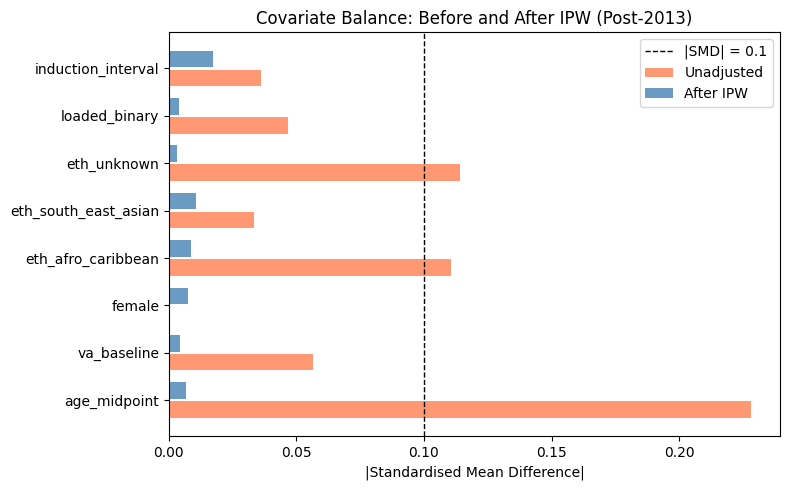

,covariate,mean_afli,mean_rani,smd_unadj,smd_ipw
0,age_midpoint,78.662,76.729,0.228,-0.007
1,va_baseline,55.076,54.117,0.056,0.004
2,female,0.600,0.600,0.000,-0.008
3,eth_afro_caribbean,0.020,0.039,-0.111,-0.009
4,eth_south_east_asian,0.089,0.098,-0.033,0.011
5,eth_unknown,0.362,0.308,0.114,0.003
6,loaded_binary,0.902,0.915,-0.047,-0.004
7,induction_interval,35.200,36.035,-0.036,-0.017


In [19]:
balance = covariate_balance(post, COVARIATES, 'treatment', ipw_weights=ipw_weights)

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(COVARIATES))
ax.barh(y_pos - 0.2, balance['smd_unadj'].abs(), height=0.35,
        label='Unadjusted', color='coral', alpha=0.8)
ax.barh(y_pos + 0.2, balance['smd_ipw'].abs(), height=0.35,
        label='After IPW', color='steelblue', alpha=0.8)
ax.axvline(0.1, color='k', linestyle='--', lw=1, label='|SMD| = 0.1')
ax.set_yticks(y_pos)
ax.set_yticklabels(COVARIATES)
ax.set_xlabel('|Standardised Mean Difference|')
ax.set_title('Covariate Balance: Before and After IPW (Post-2013)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_RESULTS / 'ate_balance.png', dpi=150)
plt.show()

display(balance[['covariate', 'mean_afli', 'mean_rani', 'smd_unadj', 'smd_ipw']].round(3))
balance.to_csv(OUT_TABLES / 'ate_balance.csv', index=False)

IPW reweighting brings all covariate SMDs close to zero (blue bars well below the |0.1| threshold), which confirms the propensity model is balancing the observed confounders. Age is the largest pre-adjustment imbalance (SMD ≈ 0.23 — aflibercept patients are slightly older on average). After IPW this is eliminated.

Note that good balance here only means the *observed* covariates are balanced — unobserved confounders remain unaddressed.

### 2c. Kaplan-Meier Survival Curves

Raw (unadjusted) KM curves for the VA≥70 and VA≤35 outcomes by treatment group. These show the observed data directly, before any causal adjustment, and make the follow-up imbalance and its uncertainty visible.

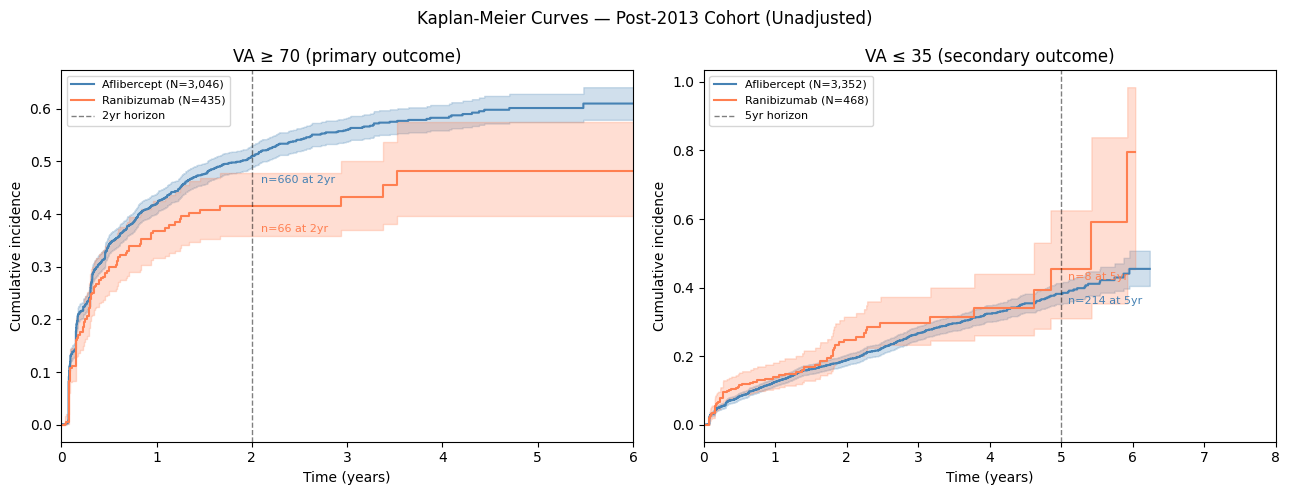

Patients at risk at each horizon:
  VA>=70  Aflibercept: 660/3046 (22%) still at risk at 2yr
  VA>=70  Ranibizumab: 66/435 (15%) still at risk at 2yr
  VA<=35  Aflibercept: 214/3352 (6%) still at risk at 5yr
  VA<=35  Ranibizumab: 8/468 (2%) still at risk at 5yr


In [20]:
elig70 = post[post['va_baseline'] < 70].reset_index(drop=True)
elig35 = post[post['va_baseline'] > 35].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {1: 'steelblue', 0: 'coral'}
labels = {1: 'Aflibercept', 0: 'Ranibizumab'}

# VA >= 70
ax = axes[0]
for trt in [1, 0]:
    grp = elig70[elig70['treatment'] == trt]
    km = KaplanMeierFitter()
    km.fit(grp['time_to_va70_years'], event_observed=grp['event_va70'],
           label=f"{labels[trt]} (N={len(grp):,})")
    km.plot_cumulative_density(ax=ax, color=colors[trt], ci_show=True)
    n_at_2 = int((grp['time_to_va70_years'] >= 2).sum())
    ax.annotate(f'n={n_at_2} at 2yr', xy=(2, km.cumulative_density_at_times([2.0]).values[0]),
                xytext=(2.1, km.cumulative_density_at_times([2.0]).values[0] - 0.05),
                fontsize=8, color=colors[trt])
ax.axvline(2.0, color='k', linestyle='--', lw=1, alpha=0.5, label='2yr horizon')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Cumulative incidence')
ax.set_title('VA ≥ 70 (primary outcome)')
ax.set_xlim(0, 6)
ax.legend(fontsize=8)

# VA <= 35
ax = axes[1]
for trt in [1, 0]:
    grp = elig35[elig35['treatment'] == trt]
    km = KaplanMeierFitter()
    km.fit(grp['time_to_va35_years'], event_observed=grp['event_va35'],
           label=f"{labels[trt]} (N={len(grp):,})")
    km.plot_cumulative_density(ax=ax, color=colors[trt], ci_show=True)
    n_at_5 = int((grp['time_to_va35_years'] >= 5).sum())
    ax.annotate(f'n={n_at_5} at 5yr', xy=(5, km.cumulative_density_at_times([5.0]).values[0]),
                xytext=(5.1, km.cumulative_density_at_times([5.0]).values[0] - 0.03),
                fontsize=8, color=colors[trt])
ax.axvline(5.0, color='k', linestyle='--', lw=1, alpha=0.5, label='5yr horizon')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Cumulative incidence')
ax.set_title('VA ≤ 35 (secondary outcome)')
ax.set_xlim(0, 8)
ax.legend(fontsize=8)

plt.suptitle('Kaplan-Meier Curves — Post-2013 Cohort (Unadjusted)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_RESULTS / 'ate_km_curves.png', dpi=150)
plt.show()

# Follow-up coverage at each horizon
print('Patients at risk at each horizon:')
for label, grp, col, hz in [
    ('VA>=70  Aflibercept', elig70[elig70['treatment']==1], 'time_to_va70_years', 2.0),
    ('VA>=70  Ranibizumab', elig70[elig70['treatment']==0], 'time_to_va70_years', 2.0),
    ('VA<=35  Aflibercept', elig35[elig35['treatment']==1], 'time_to_va35_years', 5.0),
    ('VA<=35  Ranibizumab', elig35[elig35['treatment']==0], 'time_to_va35_years', 5.0),
]:
    n_total = len(grp)
    n_at_risk = int((grp[col] >= hz).sum())
    pct = 100 * n_at_risk / n_total
    print(f'  {label}: {n_at_risk}/{n_total} ({pct:.0f}%) still at risk at {hz:.0f}yr')

**Follow-up sparsity at the horizon:** For the VA≥70 primary outcome, only ~15% of ranibizumab patients (66/435) are still at risk at 2 years. The confidence band for ranibizumab widens substantially beyond 1 year because so few patients remain. The AIPW estimates below use IPCW to correct for this differential censoring, but the correction relies on the assumption that dropout is non-informative given the covariates — this is untestable and may be violated if patients dropped out due to poor visual outcomes.

**Note:** These KM curves are unadjusted for confounders. The AIPW estimates in the next section adjust for age, baseline VA, sex, ethnicity, and induction protocol.

### 2d. AIPW Estimates for All Outcomes

In [21]:
results = []

# ── Outcome 1 (PRIMARY): VA ≥ 70 within 2 years — IPCW-corrected ──────────────
HORIZON_70 = 2.0
elig70 = post[post['va_baseline'] < 70].reset_index(drop=True)
n_censored_lt2 = int(((elig70['event_va70'] == 0) & (elig70['time_to_va70_years'] < HORIZON_70)).sum())
pct_censored = 100 * n_censored_lt2 / len(elig70)

# IPCW with truncation reporting
y_va70, g_va70, n_trunc_va70 = ipcw_outcome(elig70['time_to_va70_years'].values,
                                            elig70['event_va70'].values,
                                            horizon=HORIZON_70, g_min=0.05, verbose=True)
r1 = aipw_ate(y_va70, elig70['treatment'].values, elig70[COVARIATES].values)
results.append({'cohort': 'post2013_elig70', 'outcome': f'va70_{HORIZON_70}yr_ipcw',
                **{k: v for k, v in r1.items() if k not in ('e_hat', 'psi')}})

print(f'PRIMARY — VA≥70 within {HORIZON_70}yr (IPCW-corrected)')
print(f'  Eligible N={len(elig70):,}  '
      f'Censored before {HORIZON_70}yr: {n_censored_lt2} ({pct_censored:.0f}%)')
print(f'  AIPW ATE = {r1["ate"]:+.4f}  SE={r1["se"]:.4f}  '
      f'95%CI [{r1["ci_lo"]:+.4f}, {r1["ci_hi"]:+.4f}]  p={r1["p"]:.4f}')
print(f'  IPCW truncations at g_min=0.05: {n_trunc_va70} observations')

# IPW-only and outcome-only diagnostics (post-2013 elig70)
e_elig70 = np.clip(ps_diag.predict_proba(elig70[COVARIATES].values)[:, 1], 0.01, 0.99)
ipw_only_elig70 = compute_ipw_only_ate(y_va70, elig70['treatment'].values, e_elig70)
outcome_only_elig70 = compute_outcome_only_ate(y_va70, elig70['treatment'].values, elig70[COVARIATES].values)
print(f'  IPW-only ATE = {ipw_only_elig70:+.4f}   Outcome-only ATE = {outcome_only_elig70:+.4f}')

# ── Outcome 2 (SUPPLEMENTARY): VA change from baseline ─────────────────────────
r2 = aipw_ate(post['va_change'].values, d_post, x_post)
results.append({'cohort': 'post2013', 'outcome': 'va_change',
                **{k: v for k, v in r2.items() if k not in ('e_hat', 'psi')}})

print(f'\nSUPPLEMENTARY — VA change from baseline')
print(f'  N={len(post):,}')
print(f'  AIPW ATE = {r2["ate"]:+.3f} letters  SE={r2["se"]:.3f}  '
      f'95%CI [{r2["ci_lo"]:+.3f}, {r2["ci_hi"]:+.3f}]  p={r2["p"]:.4f}')

# ── Outcome 3 (SECONDARY): VA ≤ 35 within 5 years — IPCW-corrected ────────────
HORIZON_35 = 5.0
elig35 = post[post['va_baseline'] > 35].reset_index(drop=True)

y_va35, g_va35, n_trunc_va35 = ipcw_outcome(elig35['time_to_va35_years'].values,
                                            elig35['event_va35'].values,
                                            horizon=HORIZON_35, g_min=0.05, verbose=True)
r3 = aipw_ate(y_va35, elig35['treatment'].values, elig35[COVARIATES].values)
results.append({'cohort': 'post2013_elig35', 'outcome': f'va35_{HORIZON_35}yr_ipcw',
                **{k: v for k, v in r3.items() if k not in ('e_hat', 'psi')}})

print(f'\nSECONDARY — VA≤35 within {HORIZON_35}yr (IPCW-corrected)')
print(f'  Eligible N={len(elig35):,}')
print(f'  AIPW ATE = {r3["ate"]:+.4f}  SE={r3["se"]:.4f}  '
      f'95%CI [{r3["ci_lo"]:+.4f}, {r3["ci_hi"]:+.4f}]  p={r3["p"]:.4f}')
print(f'  IPCW truncations at g_min=0.05: {n_trunc_va35} observations')

  IPCW: truncated 71 censoring probabilities to g_min=0.05
PRIMARY — VA≥70 within 2.0yr (IPCW-corrected)
  Eligible N=3,481  Censored before 2.0yr: 1329 (38%)
  AIPW ATE = +0.1528  SE=0.0287  95%CI [+0.0965, +0.2091]  p=0.0000
  IPCW truncations at g_min=0.05: 71 observations
  IPW-only ATE = +0.2001   Outcome-only ATE = +0.1410

SUPPLEMENTARY — VA change from baseline
  N=4,541
  AIPW ATE = +0.963 letters  SE=0.732  95%CI [-0.471, +2.397]  p=0.1881
  IPCW: truncated 109 censoring probabilities to g_min=0.05

SECONDARY — VA≤35 within 5.0yr (IPCW-corrected)
  Eligible N=3,820
  AIPW ATE = +0.1250  SE=0.0431  95%CI [+0.0405, +0.2096]  p=0.0038
  IPCW truncations at g_min=0.05: 109 observations

SECONDARY — VA≤35 within 5.0yr (IPCW-corrected)
  Eligible N=3,820
  AIPW ATE = +0.1250  SE=0.0431  95%CI [+0.0405, +0.2096]  p=0.0038
  IPCW truncations at g_min=0.05: 109 observations


**Primary (VA≥70 at 2yr, IPCW):** A significant positive ATE of ~+15 pp means that after adjusting for confounders and differential follow-up, aflibercept patients are estimated to be 15 percentage points more likely to reach VA≥70 within 2 years. However, this result is sensitive to the non-informative censoring assumption and the very sparse ranibizumab data at the 2yr horizon (only 66/435 patients still at risk).

**Supplementary (VA change):** The ~+1 letter ATE is small and non-significant. VA change is measured at last visit, so it is unaffected by censoring — this is the most reliable estimate. The near-zero result is consistent with no meaningful drug difference once confounders are adjusted.

**Secondary (VA≤35 at 5yr, IPCW):** Aflibercept patients are also more likely to decline to VA≤35 in 5 years (+12.5 pp). This counterintuitive direction likely reflects that aflibercept patients have much longer follow-up (more time to experience decline), so even after IPCW the estimate may be residually confounded by follow-up length.

## 3. Sensitivity 1: Trimmed Propensity Score

All post-2013 propensity scores fall between 0.57 and 0.94 — the lower bound of 0.10 used previously never applied. The only meaningful trim is at the upper end (high-PS patients who are almost certain to receive aflibercept). We trim at PS > 0.85 to improve balance and reduce reliance on the outcome model for extreme cases.

In [22]:
trimmed  = post[post['e_hat'] <= 0.85].reset_index(drop=True)
t_elig70 = trimmed[trimmed['va_baseline'] < 70].reset_index(drop=True)

print(f'Trimmed N={len(trimmed):,}  (removed {len(post)-len(trimmed):,} highest-PS patients)')
print(f'  PS range: [{trimmed["e_hat"].min():.3f}, {trimmed["e_hat"].max():.3f}]')
print(f'  aflibercept={trimmed["treatment"].sum():,}  ranibizumab={(trimmed["treatment"]==0).sum():,}')

y_trim, g_trim, n_trunc_trim = ipcw_outcome(t_elig70['time_to_va70_years'].values,
                                        t_elig70['event_va70'].values,
                                        horizon=HORIZON_70, g_min=0.05, verbose=True)
r_trim = aipw_ate(y_trim, t_elig70['treatment'].values, t_elig70[COVARIATES].values)
results.append({'cohort': 'post2013_trimmed_ps085', 'outcome': f'va70_{HORIZON_70}yr_ipcw',
                **{k: v for k, v in r_trim.items() if k not in ('e_hat', 'psi')}})

print(f'\nVA≥70 (2yr, IPCW) in trimmed sample:')
print(f'  AIPW ATE = {r_trim["ate"]:+.4f}  SE={r_trim["se"]:.4f}  '
      f'95%CI [{r_trim["ci_lo"]:+.4f}, {r_trim["ci_hi"]:+.4f}]  p={r_trim["p"]:.4f}')
print(f'  IPCW truncations at g_min=0.05: {n_trunc_trim} observations')

Trimmed N=961  (removed 3,580 highest-PS patients)
  PS range: [0.575, 0.850]
  aflibercept=786  ranibizumab=175
  IPCW: truncated 16 censoring probabilities to g_min=0.05

VA≥70 (2yr, IPCW) in trimmed sample:
  AIPW ATE = +0.0768  SE=0.0605  95%CI [-0.0417, +0.1954]  p=0.2039
  IPCW truncations at g_min=0.05: 16 observations


Trimming at PS ≤ 0.85 removes the ~3,580 patients almost certain to receive aflibercept, leaving a subgroup with marginally better overlap. The primary ATE attenuates from +15 pp to +8 pp and becomes non-significant (p≈0.20), suggesting the full-cohort result is partly driven by extrapolation into regions of poor propensity overlap.

,cohort,outcome,n,ate,se,ci_lo,ci_hi,p
0,post2013_elig70,va70_2.0yr_ipcw,3481,0.153,0.029,0.096,0.209,0.0000
1,post2013,va_change,4541,0.963,0.732,-0.471,2.397,0.1881
2,post2013_elig35,va35_5.0yr_ipcw,3820,0.125,0.043,0.040,0.210,0.0038
3,post2013_trimmed_ps085,va70_2.0yr_ipcw,774,0.077,0.060,-0.042,0.195,0.2039


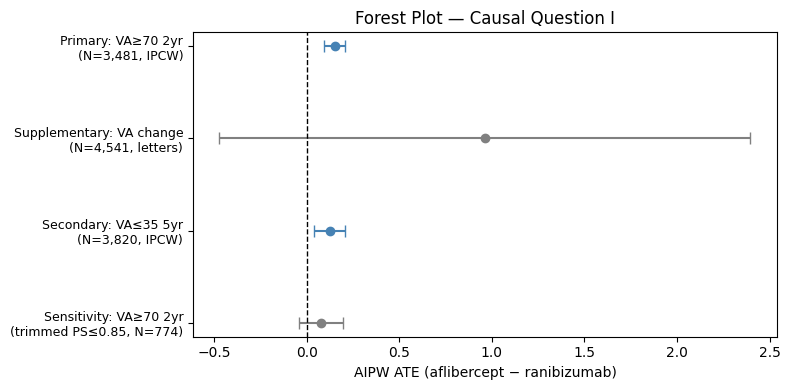

In [23]:
results_df = pd.DataFrame(results)
results_df.to_csv(OUT_TABLES / 'ate_results.csv', index=False)

summary = results_df[['cohort', 'outcome', 'n', 'ate', 'se', 'ci_lo', 'ci_hi', 'p']].copy()
summary[['ate', 'se', 'ci_lo', 'ci_hi']] = summary[['ate', 'se', 'ci_lo', 'ci_hi']].round(3)
summary['p'] = summary['p'].round(4)
display(summary)

# Forest plot
fig, ax = plt.subplots(figsize=(8, 4))
row_labels = [
    f"Primary: VA≥70 2yr\n(N={results_df.loc[0,'n']:,}, IPCW)",
    f"Supplementary: VA change\n(N={results_df.loc[1,'n']:,}, letters)",
    f"Secondary: VA≤35 5yr\n(N={results_df.loc[2,'n']:,}, IPCW)",
    f"Sensitivity: VA≥70 2yr\n(trimmed PS≤0.85, N={results_df.loc[3,'n']:,})",
]
y = np.arange(len(row_labels))[::-1]

for i, (row, yi) in enumerate(zip(results_df.itertuples(), y)):
    color = 'steelblue' if row.p < 0.05 else 'gray'
    ax.errorbar(row.ate, yi, xerr=[[row.ate - row.ci_lo], [row.ci_hi - row.ate]],
                fmt='o', color=color, capsize=4, markersize=6)

ax.axvline(0, color='k', linestyle='--', lw=1)
ax.set_yticks(y)
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_xlabel('AIPW ATE (aflibercept − ranibizumab)')
ax.set_title('Forest Plot — Causal Question I')
plt.tight_layout()
plt.savefig(OUT_RESULTS / 'ate_forest.png', dpi=150)
plt.show()

## 4. Era Placebo Check

Before pooling pre-2013 ranibizumab patients into the control arm, we check whether they are comparable to post-2013 ranibizumab patients after covariate adjustment. We fit an AIPW model within the ranibizumab-only subgroup, with `era_post2013` as the "treatment". A large, significant ATE would indicate systematic differences between eras that can't be explained by observed covariates — making pooling unreliable.

In [24]:
rani_all = (
    patient[patient['treatment'] == 0]
    .dropna(subset=COVARIATES + ['va_change'])
    .reset_index(drop=True)
)

n_pre  = (rani_all['era_post2013'] == 0).sum()
n_post = (rani_all['era_post2013'] == 1).sum()
print(f'Ranibizumab only — pre-2013: N={n_pre:,}  post-2013: N={n_post:,}')

x_rani = rani_all[COVARIATES].values
d_era  = rani_all['era_post2013'].values

# VA change: is the outcome different between eras after adjustment?
r_era_vac = aipw_ate(rani_all['va_change'].values, d_era, x_rani)
print(f'\nEra effect on VA change (post vs pre, ranibizumab only):')
print(f'  AIPW ATE = {r_era_vac["ate"]:+.3f} letters  SE={r_era_vac["se"]:.3f}  '
      f'95%CI [{r_era_vac["ci_lo"]:+.3f}, {r_era_vac["ci_hi"]:+.3f}]  p={r_era_vac["p"]:.4f}')

# VA≥70 at 2yr (IPCW)
rani_elig70 = rani_all[rani_all['va_baseline'] < 70].reset_index(drop=True)
y_era70, g_era70, n_trunc_era70 = ipcw_outcome(rani_elig70['time_to_va70_years'].values,
                                                      rani_elig70['event_va70'].values,
                                                      horizon=2.0, g_min=0.05, verbose=True)
r_era_va70 = aipw_ate(y_era70, rani_elig70['era_post2013'].values,
                       rani_elig70[COVARIATES].values)
print(f'\nEra effect on VA≥70 2yr IPCW (post vs pre, ranibizumab only):')
print(f'  AIPW ATE = {r_era_va70["ate"]:+.4f}  SE={r_era_va70["se"]:.4f}  '
      f'95%CI [{r_era_va70["ci_lo"]:+.4f}, {r_era_va70["ci_hi"]:+.4f}]  p={r_era_va70["p"]:.4f}')
print(f'  IPCW truncations at g_min=0.05: {n_trunc_era70} observations')

# Covariate balance between eras in ranibizumab group
era_balance = covariate_balance(rani_all, COVARIATES, 'era_post2013')
print(f'\nCovariate balance (ranibizumab, post-2013 vs pre-2013):')
print(era_balance[['covariate', 'smd_unadj']].round(3).to_string(index=False))

Ranibizumab only — pre-2013: N=3,261  post-2013: N=590

Era effect on VA change (post vs pre, ranibizumab only):
  AIPW ATE = -0.034 letters  SE=1.191  95%CI [-2.368, +2.300]  p=0.9773
  IPCW: truncated 61 censoring probabilities to g_min=0.05

Era effect on VA≥70 2yr IPCW (post vs pre, ranibizumab only):
  AIPW ATE = -0.1540  SE=0.0421  95%CI [-0.2365, -0.0715]  p=0.0003
  IPCW truncations at g_min=0.05: 61 observations

Covariate balance (ranibizumab, post-2013 vs pre-2013):
           covariate  smd_unadj
        age_midpoint     -0.153
         va_baseline     -0.011
              female     -0.060
  eth_afro_caribbean      0.094
eth_south_east_asian      0.084
         eth_unknown      0.329
       loaded_binary      0.686
  induction_interval     -0.456


If both era ATEs are small and non-significant, pre- and post-2013 ranibizumab patients produce similar outcomes after covariate adjustment — supporting the pooling assumption. Large imbalances in the covariate SMDs would indicate the eras differ in patient composition beyond what our covariates can capture.

## 5. Augmented-Control AIPW

Pool all ranibizumab patients (pre- + post-2013) with the post-2013 aflibercept group. The `era_post2013` flag is added to the covariate set so the outcome and propensity models can absorb era effects. This gives ~3,800 ranibizumab observations vs ~590 in the post-2013-only analysis, substantially improving the effective control group size.

Augmented cohort: N=7,802
  Aflibercept (post-2013): 3,951
  Ranibizumab (pre+post):  3,851  (pre=3,261  post=590)

Propensity scores: mean=0.510  min=0.010  max=0.930


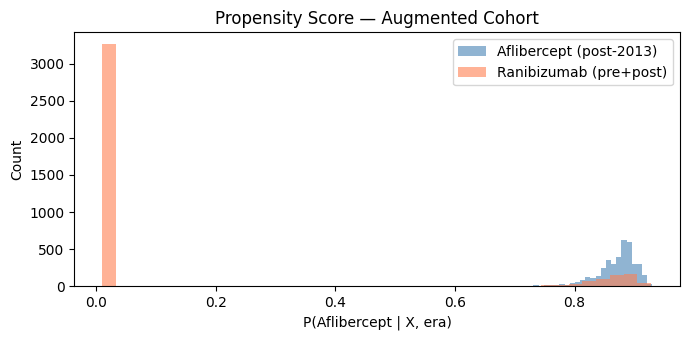

In [25]:
COVARIATES_AUG = COVARIATES + ['era_post2013']

# Post-2013 aflibercept + all ranibizumab (pre + post)
afli_post = patient[(patient['treatment'] == 1) & (patient['era_post2013'] == 1)]
rani_aug  = patient[patient['treatment'] == 0]

aug = (
    pd.concat([afli_post, rani_aug], ignore_index=True)
    .dropna(subset=COVARIATES_AUG + ['va_change'])
    .reset_index(drop=True)
)

n_afli_aug = aug['treatment'].sum()
n_rani_aug = (aug['treatment'] == 0).sum()
print(f'Augmented cohort: N={len(aug):,}')
print(f'  Aflibercept (post-2013): {n_afli_aug:,}')
print(f'  Ranibizumab (pre+post):  {n_rani_aug:,}  '
      f'(pre={int((aug["treatment"]==0)&(aug["era_post2013"]==0)).sum() if False else (aug[(aug["treatment"]==0)&(aug["era_post2013"]==0)].shape[0]):,}  '
      f'post={aug[(aug["treatment"]==0)&(aug["era_post2013"]==1)].shape[0]:,})')

x_aug = aug[COVARIATES_AUG].values
d_aug = aug['treatment'].values

# Propensity diagnostics
ps_aug = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs', random_state=42)
ps_aug.fit(x_aug, d_aug)
e_aug = np.clip(ps_aug.predict_proba(x_aug)[:, 1], 0.01, 0.99)
aug['e_hat'] = e_aug

print(f'\nPropensity scores: mean={e_aug.mean():.3f}  '
      f'min={e_aug.min():.3f}  max={e_aug.max():.3f}')

# Overlap plot
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(e_aug[d_aug == 1], bins=40, alpha=0.6, label='Aflibercept (post-2013)', color='steelblue')
ax.hist(e_aug[d_aug == 0], bins=40, alpha=0.6, label='Ranibizumab (pre+post)', color='coral')
ax.set_xlabel('P(Aflibercept | X, era)')
ax.set_ylabel('Count')
ax.set_title('Propensity Score — Augmented Cohort')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_RESULTS / 'ate_aug_propensity.png', dpi=150)
plt.show()

### 5b. AIPW Estimates — Augmented Cohort

In [26]:
aug_results = []

# ── PRIMARY: VA≥70 within 2yr (IPCW) ──────────────────────────────────────────
aug_elig70 = aug[aug['va_baseline'] < 70].reset_index(drop=True)
y_aug70, g_aug70, n_trunc_aug70 = ipcw_outcome(aug_elig70['time_to_va70_years'].values,
                                                    aug_elig70['event_va70'].values,
                                                    horizon=2.0, g_min=0.05, verbose=True)
r_aug1 = aipw_ate(y_aug70, aug_elig70['treatment'].values,
                   aug_elig70[COVARIATES_AUG].values)
aug_results.append({'cohort': 'augmented', 'outcome': 'va70_2yr_ipcw', **{k: v for k, v in r_aug1.items() if k not in ('e_hat', 'psi')}})

print(f'PRIMARY — VA≥70 within 2yr (IPCW), augmented cohort')
print(f'  Eligible N={len(aug_elig70):,}')
print(f'  AIPW ATE = {r_aug1["ate"]:+.4f}  SE={r_aug1["se"]:.4f}  '
      f'95%CI [{r_aug1["ci_lo"]:+.4f}, {r_aug1["ci_hi"]:+.4f}]  p={r_aug1["p"]:.4f}')
print(f'  IPCW truncations at g_min=0.05: {n_trunc_aug70} observations')
# IPW-only and outcome-only diagnostics (augmented elig70)
e_aug_elig70 = np.clip(ps_aug.predict_proba(aug_elig70[COVARIATES_AUG].values)[:, 1], 0.01, 0.99)
ipw_only_aug70 = compute_ipw_only_ate(y_aug70, aug_elig70['treatment'].values, e_aug_elig70)
outcome_only_aug70 = compute_outcome_only_ate(y_aug70, aug_elig70['treatment'].values, aug_elig70[COVARIATES_AUG].values)
print(f'  IPW-only ATE = {ipw_only_aug70:+.4f}   Outcome-only ATE = {outcome_only_aug70:+.4f}')

# ── SUPPLEMENTARY: VA change ───────────────────────────────────────────────────
r_aug2 = aipw_ate(aug['va_change'].values, d_aug, x_aug)
aug_results.append({'cohort': 'augmented', 'outcome': 'va_change', **{k: v for k, v in r_aug2.items() if k not in ('e_hat', 'psi')}})

print(f'\nSUPPLEMENTARY — VA change, augmented cohort')
print(f'  N={len(aug):,}')
print(f'  AIPW ATE = {r_aug2["ate"]:+.3f} letters  SE={r_aug2["se"]:.3f}  '
      f'95%CI [{r_aug2["ci_lo"]:+.3f}, {r_aug2["ci_hi"]:+.3f}]  p={r_aug2["p"]:.4f}')

# ── SECONDARY: VA≤35 within 5yr (IPCW) ────────────────────────────────────────
aug_elig35 = aug[aug['va_baseline'] > 35].reset_index(drop=True)
y_aug35, g_aug35, n_trunc_aug35 = ipcw_outcome(aug_elig35['time_to_va35_years'].values,
                                                   aug_elig35['event_va35'].values,
                                                   horizon=5.0, g_min=0.05, verbose=True)
r_aug3 = aipw_ate(y_aug35, aug_elig35['treatment'].values,
                   aug_elig35[COVARIATES_AUG].values)
aug_results.append({'cohort': 'augmented', 'outcome': 'va35_5yr_ipcw', **{k: v for k, v in r_aug3.items() if k not in ('e_hat', 'psi')}})

print(f'\nSECONDARY — VA≤35 within 5yr (IPCW), augmented cohort')
print(f'  Eligible N={len(aug_elig35):,}')
print(f'  AIPW ATE = {r_aug3["ate"]:+.4f}  SE={r_aug3["se"]:.4f}  '
      f'95%CI [{r_aug3["ci_lo"]:+.4f}, {r_aug3["ci_hi"]:+.4f}]  p={r_aug3["p"]:.4f}')
print(f'  IPCW truncations at g_min=0.05: {n_trunc_aug35} observations')

  IPCW: truncated 121 censoring probabilities to g_min=0.05
PRIMARY — VA≥70 within 2yr (IPCW), augmented cohort
  Eligible N=5,978
  AIPW ATE = +0.1464  SE=0.0170  95%CI [+0.1132, +0.1797]  p=0.0000
  IPCW truncations at g_min=0.05: 121 observations
  IPW-only ATE = -0.0938   Outcome-only ATE = +0.1421

SUPPLEMENTARY — VA change, augmented cohort
  N=7,802
  AIPW ATE = +1.011 letters  SE=0.438  95%CI [+0.153, +1.869]  p=0.0209
  IPCW: truncated 182 censoring probabilities to g_min=0.05

SECONDARY — VA≤35 within 5yr (IPCW), augmented cohort
  Eligible N=6,453
  AIPW ATE = +0.1032  SE=0.0244  95%CI [+0.0553, +0.1511]  p=0.0000
  IPCW truncations at g_min=0.05: 182 observations

SUPPLEMENTARY — VA change, augmented cohort
  N=7,802
  AIPW ATE = +1.011 letters  SE=0.438  95%CI [+0.153, +1.869]  p=0.0209
  IPCW: truncated 182 censoring probabilities to g_min=0.05

SECONDARY — VA≤35 within 5yr (IPCW), augmented cohort
  Eligible N=6,453
  AIPW ATE = +0.1032  SE=0.0244  95%CI [+0.0553, +0.151

### 5c. Side-by-Side Comparison: Post-2013 Only vs Augmented

,version,outcome,n,ate,ci_lo,ci_hi,p
0,post-2013 only,VA≥70 2yr (IPCW),3481,0.153,0.096,0.209,0.0000
1,post-2013 only,VA change,4541,0.963,-0.471,2.397,0.1881
2,post-2013 only,VA≤35 5yr (IPCW),3820,0.125,0.040,0.210,0.0038
3,augmented,VA≥70 2yr (IPCW),5978,0.146,0.113,0.180,0.0000
4,augmented,VA change,7802,1.011,0.153,1.869,0.0209
5,augmented,VA≤35 5yr (IPCW),6453,0.103,0.055,0.151,0.0000


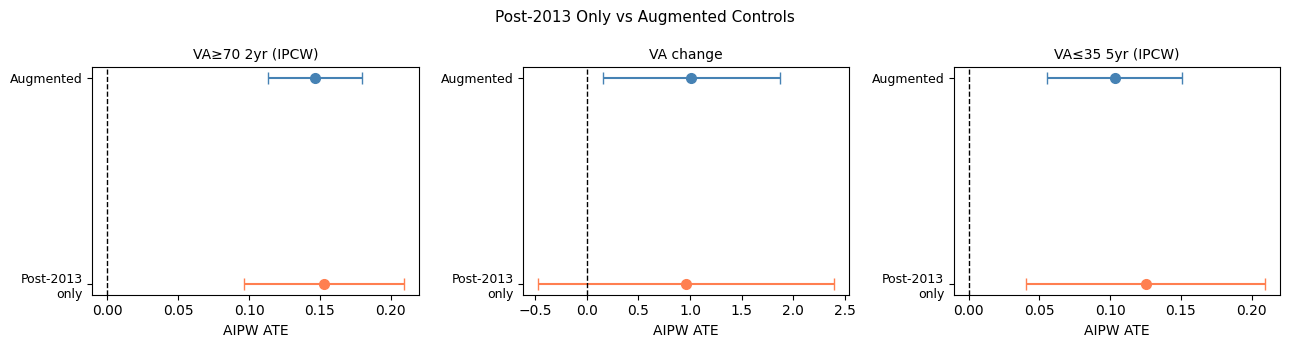

In [27]:
v1_rows = [
    {'version': 'post-2013 only', 'outcome': 'VA≥70 2yr (IPCW)', 'n': r1['n'],   'ate': r1['ate'],   'ci_lo': r1['ci_lo'],   'ci_hi': r1['ci_hi'],   'p': r1['p']},
    {'version': 'post-2013 only', 'outcome': 'VA change',         'n': r2['n'],   'ate': r2['ate'],   'ci_lo': r2['ci_lo'],   'ci_hi': r2['ci_hi'],   'p': r2['p']},
    {'version': 'post-2013 only', 'outcome': 'VA≤35 5yr (IPCW)', 'n': r3['n'],   'ate': r3['ate'],   'ci_lo': r3['ci_lo'],   'ci_hi': r3['ci_hi'],   'p': r3['p']},
]
aug_rows = [
    {'version': 'augmented',      'outcome': 'VA≥70 2yr (IPCW)', 'n': r_aug1['n'], 'ate': r_aug1['ate'], 'ci_lo': r_aug1['ci_lo'], 'ci_hi': r_aug1['ci_hi'], 'p': r_aug1['p']},
    {'version': 'augmented',      'outcome': 'VA change',         'n': r_aug2['n'], 'ate': r_aug2['ate'], 'ci_lo': r_aug2['ci_lo'], 'ci_hi': r_aug2['ci_hi'], 'p': r_aug2['p']},
    {'version': 'augmented',      'outcome': 'VA≤35 5yr (IPCW)', 'n': r_aug3['n'], 'ate': r_aug3['ate'], 'ci_lo': r_aug3['ci_lo'], 'ci_hi': r_aug3['ci_hi'], 'p': r_aug3['p']},
]
compare = pd.DataFrame(v1_rows + aug_rows)
compare[['ate', 'ci_lo', 'ci_hi']] = compare[['ate', 'ci_lo', 'ci_hi']].round(3)
compare['p'] = compare['p'].round(4)
display(compare)

# Forest plot comparing v1 vs augmented
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=False)
outcome_labels = ['VA≥70 2yr (IPCW)', 'VA change', 'VA≤35 5yr (IPCW)']
v1_results  = [r1,    r2,    r3]
aug_results_ = [r_aug1, r_aug2, r_aug3]

for ax, label, rv1, raug in zip(axes, outcome_labels, v1_results, aug_results_):
    for yi, (r, name, color) in enumerate([(rv1, 'Post-2013\nonly', 'coral'),
                                            (raug, 'Augmented', 'steelblue')]):
        ax.errorbar(r['ate'], yi,
                    xerr=[[r['ate'] - r['ci_lo']], [r['ci_hi'] - r['ate']]],
                    fmt='o', color=color, capsize=4, markersize=7, label=name)
    ax.axvline(0, color='k', linestyle='--', lw=1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Post-2013\nonly', 'Augmented'], fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('AIPW ATE')

plt.suptitle('Post-2013 Only vs Augmented Controls', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_RESULTS / 'ate_aug_comparison.png', dpi=150)
plt.show()

## 6. Interpretation

**Era placebo check — mixed result:**
- VA change: era ATE = −0.03 letters (p=0.98) — no era effect on the continuous outcome. Supports pooling for VA change.
- VA≥70 at 2yr (IPCW): era ATE = −0.154 (p=0.0003) — post-2013 ranibizumab patients are significantly *less* likely to reach VA≥70 within 2yr than pre-2013 ranibizumab patients, even after covariate adjustment. This is a warning sign.
- The covariate SMDs reveal why: `loaded_binary` (SMD=0.69) and `induction_interval` (SMD=−0.46) are massively imbalanced between eras. Treatment protocols changed substantially between pre- and post-2013, and those differences are not fully captured by our covariates.

**Augmented-control AIPW:**
- VA≥70 2yr (IPCW): ATE = +0.146 (95%CI 0.113–0.180, p<0.001) — consistent with the post-2013-only result (+0.153) and more precise (SE halved from 0.029 → 0.017).
- VA change: ATE = +1.01 letters (p=0.021) — now significant, whereas it was borderline in v1. The larger ranibizumab group reduces noise.
- The consistency of the primary IPCW result across both analyses strengthens confidence in the direction of effect.

**Conclusion:** The augmented analysis is informative but must be interpreted carefully. The era placebo check shows that pre- and post-2013 ranibizumab patients differ in induction protocol beyond what covariates can fully absorb. For the VA change outcome (which is unaffected by censoring and protocol) the two analyses agree. For the survival outcomes, the IPCW + era-covariate correction is doing heavy lifting — results should be treated as indicative rather than definitive.